# AML Risk Scoring & Alert Triage System

## Overview
This project simulates a Level 1 Anti-Money Laundering (AML) transaction monitoring triage system used in financial institutions & represents a typical rules-based transaction monitoring system used in early-stage alert triage (Level 1 review).

It assigns risk scores to customers based on key financial crime risk indicators such as transaction amount, transaction frequency, Politically Exposed Person (PEP) status, sanctions exposure, country risk, and account age.

The model demonstrates how alerts can be prioritised to support efficient investigation workflows.

---

## Objective
- Assign risk scores to customers based on AML risk indicators  
- Classify alerts into High, Medium, and Low risk categories  
- Prioritise alerts for investigation  
- Simulate real-world transaction monitoring workflows  

---

## Summary
This project demonstrates a rules-based AML risk scoring and alert triage system that prioritises high-risk customers using weighted financial crime risk indicators.

It reflects how transaction monitoring systems operate in practice, where alerts are generated and triaged to ensure that higher-risk cases are escalated for immediate review.

The project also highlights how structured, data-driven approaches can:
- Improve alert prioritisation  
- Reduce false positives  
- Enhance investigator productivity  
- Increase risk visibility across customer portfolios 

This mirrors how transaction monitoring systems triage alerts before escalation to Level 2 investigations.

#### Libraries

In [1]:
import pandas as pd

#### Data

In [2]:
data = {
    "customer_id": ["C001", "C002", "C003", "C004", "C005"],
    "transaction_amount": [50000, 200, 15000, 30000, 800],
    "txn_count_7d": [15, 2, 8, 12, 1],
    "is_pep": ["Yes", "No", "No", "No", "No"],
    "is_sanction_hit": ["No", "No", "Yes", "No", "No"],
    "country": ["HighRiskCountry", "LowRiskCountry", "MediumRiskCountry", "HighRiskCountry", "LowRiskCountry"],
    "account_age_days": [10, 200, 50, 20, 400]
}

df = pd.DataFrame(data)
df

,customer_id,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,country,account_age_days
0,C001,50000,15,Yes,No,HighRiskCountry,10
1,C002,200,2,No,No,LowRiskCountry,200
2,C003,15000,8,No,Yes,MediumRiskCountry,50
3,C004,30000,12,No,No,HighRiskCountry,20
4,C005,800,1,No,No,LowRiskCountry,400


#### Risk scoring logic

In [3]:
HIGH_RISK_COUNTRIES = {"HighRiskCountry"}

def calculate_risk_score(row):
    score = 0

    if row["country"] in HIGH_RISK_COUNTRIES:
        score += 30

    if float(row["transaction_amount"]) > 20000:
        score += 20

    if int(row["txn_count_7d"]) > 10:
        score += 20

    if str(row["is_pep"]).lower() == "yes":
        score += 25

    if str(row["is_sanction_hit"]).lower() == "yes":
        score += 40

    if int(row["account_age_days"]) < 30:
        score += 15

    return score

#### Risk classification logic:

In [4]:
def classify_risk(score):
    if score >= 60:
        return "High"
    elif score >= 30:
        return "Medium"
    else:
        return "Low"

#### Apply risk scoring:

In [5]:
df["risk_score"] = df.apply(calculate_risk_score, axis=1)
df["risk_level"] = df["risk_score"].apply(classify_risk)

df

,customer_id,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,country,account_age_days,risk_score,risk_level
0,C001,50000,15,Yes,No,HighRiskCountry,10,110,High
1,C002,200,2,No,No,LowRiskCountry,200,0,Low
2,C003,15000,8,No,Yes,MediumRiskCountry,50,40,Medium
3,C004,30000,12,No,No,HighRiskCountry,20,85,High
4,C005,800,1,No,No,LowRiskCountry,400,0,Low


#### Prioritised Alert Queue - table below ranks customers by calculated risk score so that investigators can prioritise higher-risk alerts first.

In [6]:
triage_df = df.sort_values(by="risk_score", ascending=False)
triage_df

,customer_id,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,country,account_age_days,risk_score,risk_level
0,C001,50000,15,Yes,No,HighRiskCountry,10,110,High
3,C004,30000,12,No,No,HighRiskCountry,20,85,High
2,C003,15000,8,No,Yes,MediumRiskCountry,50,40,Medium
1,C002,200,2,No,No,LowRiskCountry,200,0,Low
4,C005,800,1,No,No,LowRiskCountry,400,0,Low


In [7]:
df["risk_level"].value_counts()

risk_level
High      2
Low       2
Medium    1
Name: count, dtype: int64

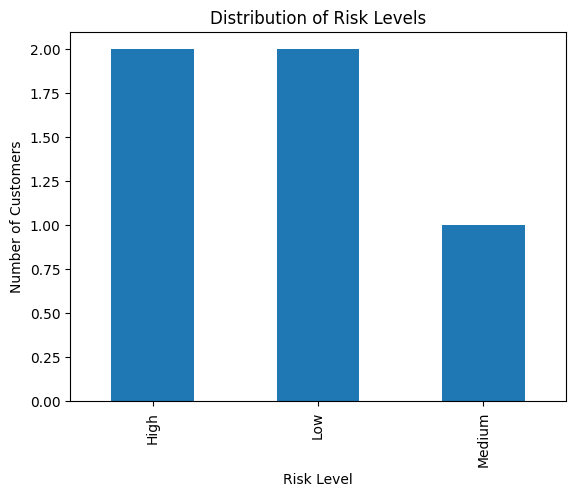

In [8]:
import matplotlib.pyplot as plt

df["risk_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()


#### Risk Distribution Insights

The dataset shows a relatively balanced distribution across risk levels, with high-risk customers clearly identifiable based on defined risk indicators.

This enables prioritisation of high-risk cases for immediate investigation while optimising resource allocation for medium- and low-risk alerts.

#### Business Impact

This model demonstrates how a rules-based scoring approach can improve alert triage efficiency by prioritising high-risk cases for investigation.

In real-world applications, such systems help:
- Reduce false positives in transaction monitoring
- Improve investigator productivity
- Enhance risk visibility across customer portfolios
- Support compliance with AML/CFT regulatory expectations

#### Risk Scoring Approach

The risk scoring model assigns weighted scores based on key AML risk indicators:

- High-risk country: +30
- Large transaction amount (>20,000): +20
- High transaction frequency (>10 in 7 days): +20
- Politically Exposed Person (PEP): +25
- Sanctions hit: +40
- New account (<30 days): +15

These weights simulate a simplified rules-based transaction monitoring system used in financial institutions.

#### Key Risk Drivers

The primary drivers of high-risk classification in this model include:

- Sanctions hits (highest impact)
- High-risk jurisdictions
- Large transaction amounts
- High transaction frequency

These factors align with common AML typologies and risk indicators used in financial institutions.

#### Future Enhancements

This model can be extended using machine learning techniques such as anomaly detection and classification models to further improve detection accuracy and reduce false positives.

In [9]:
df["alert_id"] = ["A001", "A002", "A003", "A004", "A005"]

df["alert_priority"] = df["risk_level"].map({
    "High": "Immediate Review",
    "Medium": "Review Soon",
    "Low": "Queue"
})

df[["alert_id", "customer_id", "risk_score", "risk_level", "alert_priority"]]

,alert_id,customer_id,risk_score,risk_level,alert_priority
0,A001,C001,110,High,Immediate Review
1,A002,C002,0,Low,Queue
2,A003,C003,40,Medium,Review Soon
3,A004,C004,85,High,Immediate Review
4,A005,C005,0,Low,Queue


#### Operational Considerations

While rules-based scoring helps prioritise alerts, it may also generate false positives.

In real-world applications, thresholds and scoring weights would be calibrated using historical alert outcomes to balance detection effectiveness and operational efficiency.

The model is rules-based and does not learn from historical data, which may limit adaptability and detection accuracy compared to machine learning approaches.

In [10]:
df["high_risk_flag"] = df["risk_score"] >= 60

high_risk_cases = df[df["high_risk_flag"] == True]

high_risk_cases

,customer_id,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,country,account_age_days,risk_score,risk_level,alert_id,alert_priority,high_risk_flag
0,C001,50000,15,Yes,No,HighRiskCountry,10,110,High,A001,Immediate Review,True
3,C004,30000,12,No,No,HighRiskCountry,20,85,High,A004,Immediate Review,True


#### High Risk Scenario Analysis

High-risk cases identified by the model represent customers requiring immediate investigation. These cases are driven by multiple risk indicators such as high transaction volumes, sanctions exposure, or high-risk jurisdictions.

This demonstrates how rule-based systems can be used to isolate high-priority cases for further investigation.

#### Risk Level Distribution

This chart shows the distribution of customers across risk categories based on the scoring model.

It provides a portfolio-level view of risk exposure and helps identify the proportion of high-risk customers requiring immediate attention.

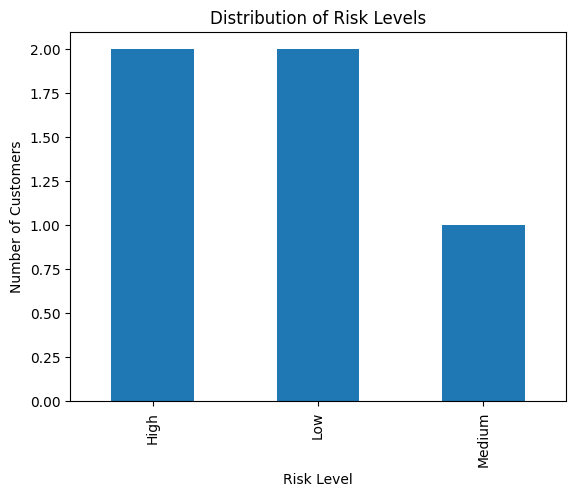

In [11]:
import matplotlib.pyplot as plt

df["risk_level"].value_counts().plot(kind="bar")

plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

#### Risk Score Distribution

This histogram shows the distribution of risk scores across customers.

It provides deeper insight into how risk is distributed within the portfolio and highlights clustering of high-risk cases, supporting more effective prioritisation and threshold calibration.

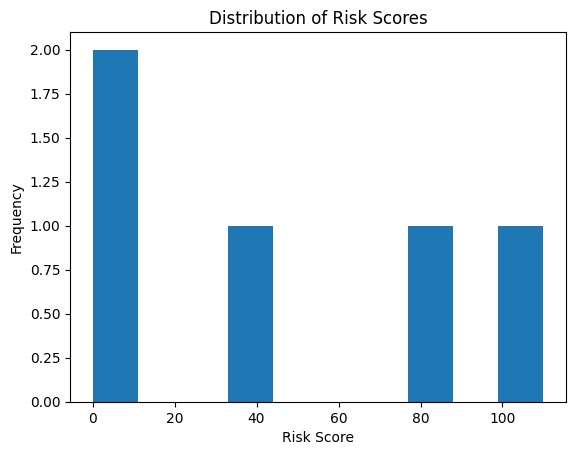

In [12]:
df["risk_score"].plot(kind="hist", bins=10)

plt.title("Distribution of Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()